# Compute wind speeds for each grid

In [42]:
# client.close()
# cluster.close()

In [1]:
from dask.distributed import Client,LocalCluster
from dask_jobqueue import PBSCluster

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [2]:
PROJECT = "dt6"

In [3]:
walltime = "01:00:00"
cores = 12
memory = str(4 * cores) + "GB"

cluster = PBSCluster(
    walltime=str(walltime),
    cores=cores,
    memory=str(memory),
    processes=cores,
    job_extra_directives=[
        "-q normal",
        "-P "+PROJECT,
        "-l ncpus="+str(cores),
        "-l mem="+str(memory),
        "-l storage=gdata/xp65+gdata/ob53+gdata/w42+scratch/w42+gdata/gb02+scratch/gb02+gdata/ng72+scratch/ng72+gdata/rt52"
    ],
    local_directory="$TMPDIR",
    job_directives_skip=["select"],
    log_directory="/scratch/w42/dr6273/tmp/logs"
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35521 instead
  warnings.warn(


In [4]:
cluster.scale(jobs=1)
client = Client(cluster)

In [5]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /proxy/35521/status,
Dashboard: /proxy/35521/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.6.121.14:34107,Workers: 0
Dashboard: /proxy/35521/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [6]:
import xarray as xr

import glob

import matplotlib.pyplot as plt

In [7]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought


In [8]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

In [9]:
# YEARS = slice("1979", "2024")

### Load data

ERA5

In [10]:
era5_10m = xr.open_zarr(
    FILEPATH + "ERA5/ws10m_era5_daily_Aus_1979-2024.zarr",
    consolidated=True
)["ws10m"]

BARRA-R2

In [11]:
barraR2_10m = xr.open_mfdataset(
    glob.glob(FILEPATH + "BARRA-R2/wss*")
)["wss"]

Grid masks

In [12]:
MASK_FILENAMES = [
    "grid_mask_NEM_era5.nc",
    "grid_mask_SWIS_era5.nc",
    "grid_mask_NWIS_era5.nc",
    "grid_mask_NEM_BARRA-R2.nc",
    "grid_mask_SWIS_BARRA-R2.nc",
    "grid_mask_NWIS_BARRA-R2.nc"
]

In [13]:
MASK_NAMES = [
    "ERA5_NEM",
    "ERA5_SWIS",
    "ERA5_NWIS",
    "BARRA-R2_NEM",
    "BARRA-R2_SWIS",
    "BARRA-R2_NWIS"
]

In [14]:
grid_masks = {}
for name, fn in zip(MASK_NAMES, MASK_FILENAMES):
    if name[-3:] == "NEM":
        grid_masks[name] = xr.open_dataset(FILEPATH + fn)
    else:
        grid_masks[name] = xr.open_dataarray(FILEPATH + fn)

### Wind speed

For each grid, compute the average wind speed per day. For the NEM, compute two versions - one where the REZs are assigned weights according to their wind power capacity and the other where the REZs are unweighted (in the same way the NWIS and SWIS are unweighted).

In [28]:
def subset_region(da, mask):
    """
    Return array for given region

    da: array to subset
    mask: array, with NaNs indicating unneeded locations
    """
    return da.where(mask.notnull(), drop=True)

In [104]:
def get_weights(mask):
    """
    Return array of weights

    mask: array, with 2 dimensions to compute weights over (usually lat and lon)
    """
    w = mask / mask.sum()
    return w.fillna(0)

In [46]:
def unweight_NEM_mask(mask):
    """
    Return binary array of mask

    mask: array of capacities
    """
    return xr.where(m.notnull(), 1, 0)

In [110]:
def compute_ws_mean(ws, mask, unweight_mask=False):
    """
    Return spatial average of wind speed over masked region

    ws: array, wind speed
    mask: array, data to mask out
    unweunweight_mask: bool, whether to use binary mask
    """
    m = subset_region(mask, mask) # drop unused grid cells from mask
    if unweight_mask:
        m = unweight_NEM_mask(m) # binary mask if desired
    m = get_weights(m)
        
    da_out = subset_region(ws, mask) # drop unused grid cells from da
    da_out = da_out.weighted(m).mean(["lat", "lon"]) # weighted mean (equivalent to da_out.mean() for binary mask)
    return da_out.chunk({"time": -1})

In [111]:
for data_name, ws_da in zip(
    ["ERA5", "BARRA-R2"],
    [era5_10m, barraR2_10m]
):
    var_name = ws_da.name
    
    for grid in ["NEM", "SWIS", "NWIS"]:
        
        if grid == "NEM":
            
            for scenario in ["wind_2025", "wind_2030", "wind_2040", "wind_2050"]:
                
                for subgrid in ["NEM", "SE"]:
                    
                    for unweight in [True, False]:
                        
                        mask = grid_masks[data_name+"_"+grid][scenario].sel(grid=subgrid).drop_vars("grid")
                        ws_mean = compute_ws_mean(ws_da, mask, unweight_mask=unweight)
                        
                        fname = "grid_mean_"+var_name+"_"+data_name+"_"+grid+"_"+scenario+"_"+subgrid+"_"
                        if unweight:
                            fname = fname+"unweighted"
                        else:
                            fname = fname+"weighted"
                            
                        ws_mean.to_netcdf(FILEPATH+fname+".nc", mode="w")
        else:
            mask = grid_masks[data_name+"_"+grid]
            ws_mean = compute_ws_mean(ws_da, mask, unweight_mask=unweight)
            
            fname = "grid_mean_"+var_name+"_"+data_name+"_"+grid
                
            ws_mean.to_netcdf(FILEPATH+fname+".nc", mode="w")

In [137]:
da1 = xr.open_dataarray(FILEPATH+"grid_mean_ws10m_ERA5_NEM_wind_2050_NEM_unweighted.nc")

In [138]:
da2 = xr.open_dataarray(FILEPATH+"grid_mean_ws10m_ERA5_NEM_wind_2025_NEM_unweighted.nc")

In [141]:
da3 = xr.open_dataarray(FILEPATH+"grid_mean_ws10m_ERA5_NEM_wind_2025_NEM_weighted.nc")

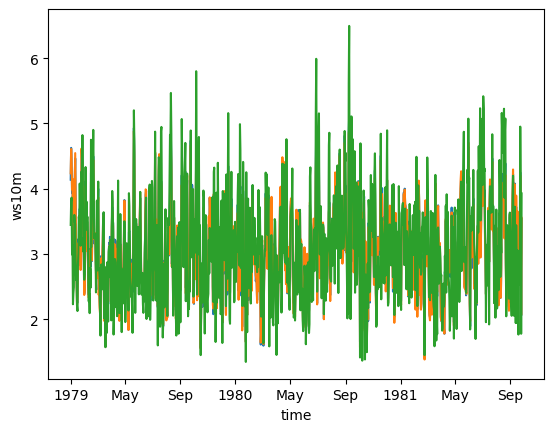

In [142]:
da1.isel(time=range(1000)).plot()
da2.isel(time=range(1000)).plot()
da3.isel(time=range(1000)).plot()

In [170]:
m1 = grid_masks["ERA5_NEM"]["wind_2025"].sel(grid="NEM")
m2 = grid_masks["ERA5_NEM"]["wind_2030"].sel(grid="NEM")
m3 = grid_masks["ERA5_NEM"]["wind_2040"].sel(grid="NEM")
m4 = grid_masks["ERA5_NEM"]["wind_2050"].sel(grid="NEM")

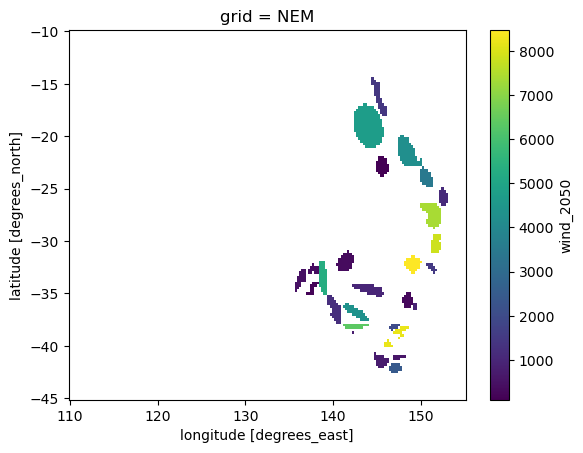

In [174]:
m4.plot()

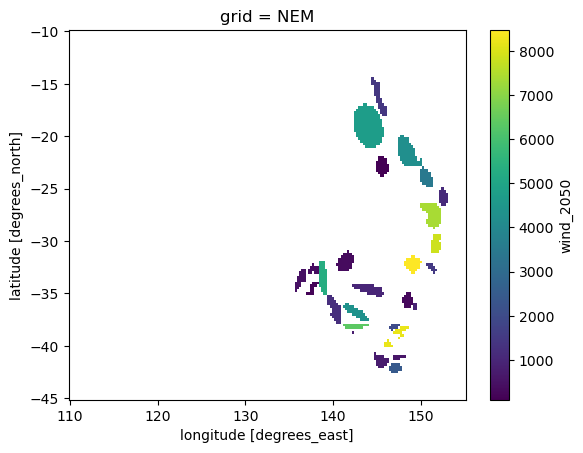

In [176]:
m4.where(m4 > 0).plot()

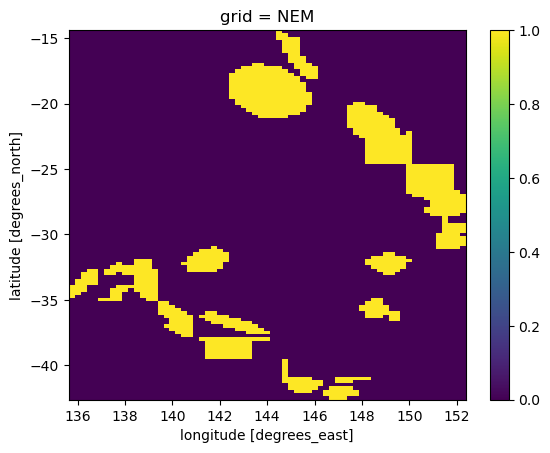

In [175]:
unweight_NEM_mask(m4).plot()

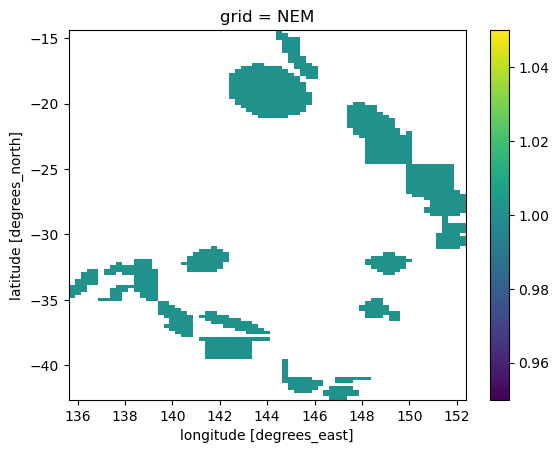

In [169]:
m4.where(m4 > 0).plot()

In [167]:
m1 = subset_region(unweight_NEM_mask(m1), m1)
m2 = subset_region(unweight_NEM_mask(m2), m2)
m3 = subset_region(unweight_NEM_mask(m3), m3)
m4 = subset_region(unweight_NEM_mask(m4), m4)

In [158]:
m = m1+m2+m3+m4

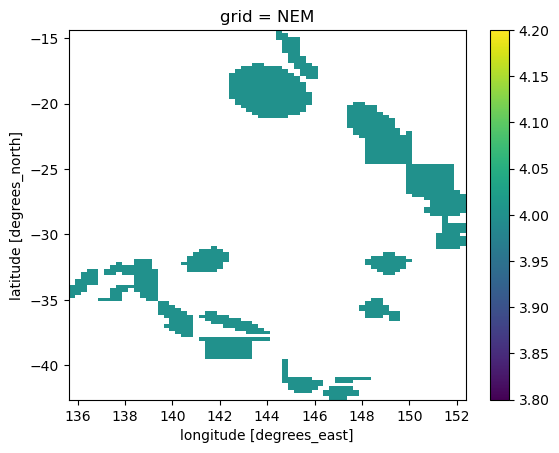

In [160]:
m.plot()